# Set up

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install sentence_transformers ;

In [3]:
!pip uninstall -y chromadb opentelemetry-api opentelemetry-sdk opentelemetry-exporter-otlp opentelemetry-exporter-otlp-proto-grpc opentelemetry-exporter-otlp-proto-http opentelemetry-exporter-gcp-trace opentelemetry-exporter-gcp-monitoring opentelemetry-exporter-gcp-logging opentelemetry-resourcedetector-gcp -q
!pip uninstall -y protobuf -q
!pip install chromadb -q
import chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 7.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currentl

In [4]:
import pandas as pd
import numpy as np


In [5]:
from google.colab import drive
drive.mount('/content/drive') # connect drive folder path

Mounted at /content/drive


In [6]:
file_path="/content/drive/MyDrive/amazon_seller_research_assitant/"

In [7]:
#make sure the path works
import os
print(os.listdir('/content/drive/MyDrive/amazon_seller_research_assitant/'))


['preprocessed_reduced.parquet', 'title_embedding_may9th.npy', 'chroma_db', 'keyword_stats.parquet', 'kitchen_lesss_than_90days.csv', 'kitchen_review_counts.csv']


In [8]:
try:
  df_raw=pd.read_parquet(f'{file_path}preprocessed_reduced.parquet')
  print("file loaded successfully")
  df_raw.head()
except FileNotFoundError:
  print("file not found")
except Exception as e:
  print(f"error found {e}")


file loaded successfully


In [64]:
df_raw.shape

(73795, 8)

In [65]:
df_raw.describe()

,month,price,most_recent_review,most_recent_review_time
count,73795,71066.000000,73795.000000,73795.000000
mean,2025-05-11 00:04:48.019513,60.440256,1.976150,133.053445
min,2024-01-01 00:00:00,-0.010000,0.000000,-1806.000000
25%,2025-01-01 00:00:00,29.990000,0.000000,39.000000
50%,2025-07-01 00:00:00,49.000000,0.000000,99.000000
75%,2025-11-01 00:00:00,79.990000,0.000000,216.000000
max,2026-03-01 00:00:00,3535.000000,197.000000,5567.000000
std,NaN,51.533232,8.641488,218.464942


In [66]:
df.isnull().sum()

,0
asin,0
seller,21
cat,3156
price,0
title,1
most_recent_review,0
most_recent_review_time,0
launch_year,0
launch_month,0
launch_year_month,0


In [67]:
# get rid of price >100 and price<15
df=df_raw[(df_raw['price']<=100) & (df_raw['price']>=15)]
# extract month and year
df['launch_year']=pd.to_datetime(df['month']).dt.year
df['launch_month']=pd.to_datetime(df['month']).dt.month
df['launch_year_month']=df['month']
df.drop('month',axis=1,inplace=True)
df.shape

(61664, 10)

In [68]:
# fill seller and cat na with unknown drop title
df.dropna(subset='title',inplace=True)
df['seller'].fillna('unkown',inplace=True)
df['cat'].fillna('unkown',inplace=True)
df.isnull().sum(0)

,0
asin,0
seller,0
cat,0
price,0
title,0
most_recent_review,0
most_recent_review_time,0
launch_year,0
launch_month,0
launch_year_month,0


# Feature Engineering

In [69]:
df['cat'].unique()

array(['Clothing, Shoes & Jewelry', 'Beauty & Personal Care',
       'Health & Household', 'Electronics', 'unkown', 'Office Products',
       'Home & Kitchen', 'Cell Phones & Accessories',
       'Arts, Crafts & Sewing', 'Automotive', 'Tools & Home Improvement',
       'Toys & Games', 'Patio, Lawn & Garden', 'Sports & Outdoors',
       'Grocery & Gourmet Food', 'Industrial & Scientific',
       'Pet Supplies', 'Musical Instruments', 'Baby Products',
       'Appliances', 'Video Games', 'Collectibles & Fine Art'],
      dtype=object)

In [70]:
# add review velocity. rule: most_recent_review_time>=90
filter=df['most_recent_review_time']>=90
df.loc[filter,'review_velocity']=df[filter]['most_recent_review']/df[filter]['most_recent_review_time']
df.loc[~filter,'review_velocity']=None
df.describe()


,price,most_recent_review,most_recent_review_time,launch_year,launch_month,launch_year_month,review_velocity
count,61663.000000,61663.000000,61663.000000,61663.000000,61663.000000,61663,32726.000000
mean,50.185312,2.065031,136.151923,2024.901189,6.396721,2025-05-08 09:18:38.654622,0.012508
min,15.000000,0.000000,-1806.000000,2024.000000,1.000000,2024-01-01 00:00:00,0.000000
25%,29.990000,0.000000,42.000000,2025.000000,3.000000,2025-01-01 00:00:00,0.000000
50%,44.950000,0.000000,99.000000,2025.000000,7.000000,2025-07-01 00:00:00,0.000000
75%,67.990000,0.000000,213.000000,2025.000000,10.000000,2025-11-01 00:00:00,0.007828
max,100.000000,197.000000,5567.000000,2026.000000,12.000000,2026-03-01 00:00:00,1.556701
std,24.291222,8.841315,205.118791,0.600252,3.757820,NaN,0.039200


In [71]:
# in later step, I found that there are 30 of entries are dupliates
# get surviving indices BEFORE reset
surviving_idx = df.drop_duplicates(subset='asin', keep='last').index.tolist()
df = df.loc[surviving_idx].reset_index(drop=True)
df.shape


(61635, 11)

In [74]:
df.to_parquet(f"{file_path}product_launch_cleaned_61635.parquet")

# Create keywords_stats table from 61635 data

In [72]:
from sklearn.feature_extraction.text import CountVectorizer
def extract_keywords():
  cv=CountVectorizer(ngram_range=(1,2)) #
  keyword_freq=cv.fit_transform(df['title'])
  # extract unigram and bigram from titles
  # increase min_df to eliminate keyword noise
  # at min_df=1, we have 300k keywords
  cv_clean=CountVectorizer(ngram_range=(1,2),min_df=10,max_df=0.8) #[1,2] means both unigram and bigram
  keyword_freq_cleaned=cv_clean.fit_transform(df['title'])
  keywords_cleaned=cv_clean.get_feature_names_out() # keyword_freq_cleaned is sparse matrix. Do not directly convert to df --> RAM run out error
  print(len(keywords_cleaned))
  return keyword_freq_cleaned,keywords_cleaned

In [73]:
def create_keywrod_stats(keyword_freq_cleaned,keywords_cleaned):
  """
  df: rows are samples, cols are features
  keyword_freq_cleaned: rows are sampels, cols are keyword
  keywords_cleaned: list of keywords

  We will need three masks to get relavant info out: per keyword, per month and per cat"""

  cats=df['cat'].unique()
  results=[]

  for cat in cats:
    mask_cat=df['cat']==cat # first filter

    for i in range(len(keywords_cleaned)): # for each keyword position also, col position for keyword_freq_cleaned
        # after applying first filter to keyword_freq_cleaned, search keyword_freq_cleaned where current column/keyword has a frequency>0
        # keyword_freq_cleaned is csr_matrix, use values to convert it to a numpy array
        # to dense to convert sparse to dense matrix
        mask_keyword=np.array(keyword_freq_cleaned[mask_cat.values][:,i].todense())>0 # second filter

        # after applying both filters to df, find out the unique months
        filtered_df_2=df[mask_cat][mask_keyword]
        months=filtered_df_2['launch_year_month'].unique()

        for month in months:

          # apply all three filters to df and get the price_median, n_product, velocity_median(tricky)
          filtered_df=filtered_df_2[filtered_df_2['launch_year_month']==month]
          n_product=filtered_df.shape[0]
          price_median=filtered_df['price'].median()

          # velocity _median needs to find rows where 'most_recent_review_time'
          filtered_df_w_review=filtered_df[filtered_df['most_recent_review_time']>=90]
          n_product_w_review=filtered_df_w_review.shape[0]
          velocity_median=filtered_df_w_review['review_velocity'].median()
          results.append({
              'keyword':keywords_cleaned[i],
              'cat':cat,
              'month':month,
              'n_product':n_product,
              'price_median':price_median,
              'velocity_median':velocity_median,
              'n_velocity_sample':n_product_w_review
          })


  keyword_stats=pd.DataFrame(results)
  keyword_stats.to_parquet(f'{file_path}keyword_stats.parquet')
  print('keyword_stas.parquet created')


In [19]:
# load or ceate keyword_stats table
import os

if os.path.exists(f"{file_path}keyword_stats.parquet"):
  print("keyword_stats.parquet already created")
else:
  print("keyword_stats.parquet not exist. creating... takes about 30 mins")
  keyword_freq_cleaned,keywords_cleaned=extract_keywords()
  create_keywrod_stats(keyword_freq_cleaned,keywords_cleaned)



keyword_stats.parquet already created


# Save to chroma_db from 61635 data

In [20]:
from sentence_transformers import SentenceTransformer

def create_embedding():
  """Creates sentence embeddings for product titles and saves them to a file."""
  # Load the pre-trained model
  model = SentenceTransformer('all-MiniLM-L6-v2')
  # Generate embeddings for the titles
  global embedding
  embedding = model.encode(df['title'].tolist(), show_progress_bar=True)
  # Save the embeddings to a .npy file
  np.save(f"{file_path}title_embedding_may9th.npy", embedding)
  print("Embeddings created and saved successfully.")

In [21]:
#get df
df=df
# load embedding
try:
  embedding=np.load(f"{file_path}title_embedding_may9th.npy")
  print("title_embedding_may9th.npy loaded from drive")
except:
  print("title_embedding_may9th.npy not found in memory. encoding...")
  create_embedding()

title_embedding_may9th.npy loaded from drive


In [62]:
assert len(df)==len(embedding)
print(len(df))



AssertionError: 

In [23]:
cols=[f"emb_{i}" for i in range(384)]
df[cols]=embedding
df.shape

(61635, 395)

In [24]:
# make connection
client=chromadb.PersistentClient(path=f"{file_path}chroma_db")
collection=client.get_or_create_collection(
    name="title_embedding_db",
    metadata={"hnsw:space": "cosine"}
)


In [25]:


# check how many are done in case of disconnetion
already_done=collection.count()
print(f"already done: {already_done}")

already done: 61635


In [26]:


# if already done, skip it completely
if already_done==len(df):
  print("chroma.db complete")
else:
  # let's add document in batches
  batch_size=1000
  for i in range(already_done,len(df),batch_size):
    # get batches's id
    batch_df=df.iloc[i:i+batch_size]
    # get batches's embedding, covert to list
    batch_embedding=embedding[i:i+batch_size].tolist()
    batch_id=batch_df['asin'].tolist()
    # covert datetime type to string
    batch_df['launch_year_month'] = batch_df['launch_year_month'].astype(str)
  # add or upsert document
    collection.upsert(
        ids=batch_id,
        embeddings=batch_embedding,
        metadatas=batch_df[['asin','seller','cat','launch_year_month','price']].to_dict('records')
        # we must use "record" in to_dict we want list of dictionary[{'title':xx,'seller": xx, "price":xx}] nor dicionary of dictionary{ 'title:{"0":spatula,"1":spoon}}
    )
    if i % 10000 == 0:
          print(f'{i}/{len(df)}')

print('Done:', collection.count())



chroma.db complete
Done: 61635


In [27]:
#check chroma_db for similarity
import time

start_time=time.time()
query_texts=['white dog clothes']

query_embedding=SentenceTransformer('all-MiniLM-L6-v2').encode(query_texts)

results=collection.query(
    query_embeddings=query_embedding,
    n_results=20
)

time_elapsed=time.time()-start_time
print(f"time used {time_elapsed}")
print(results)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

time used 18.071662425994873
{'ids': [['B0F3CQKDT1', 'B0GF98SDRQ', 'B0DPQRTYVP', 'B0GLP3L82N', 'B0FX3SGQPY', 'B0F93RRNVS', 'B0GDFCKZXM', 'B0F93RB6MW', 'B0F93R7XDX', 'B0F93QLBWB', 'B0D4DKLGXG', 'B0FJ6VX8MZ', 'B0DPQTHG6P', 'B0FMQDZ3MT', 'B0DHF56GFF', 'B0FFYPKP2F', 'B0DCLCR9MK', 'B0DJ7C253L', 'B0FKGVK6N5', 'B0DWSLPY74']], 'embeddings': None, 'documents': [[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'price': 29.99, 'asin': 'B0F3CQKDT1', 'seller': 'A1IOY66QV3PFKR', 'cat': 'Sports & Outdoors', 'launch_year_month': '2025-04-01'}, {'launch_year_month': '2026-03-01', 'asin': 'B0GF98SDRQ', 'seller': 'A3EY3LIREURE2Y', 'price': 22.49, 'cat': 'Pet Supplies'}, {'asin': 'B0DPQRTYVP', 'seller': 'A18H7KNRFCNHWY', 'price': 32.99, 'cat': 'Pet Supplies', 'launch_year_month': '2024-12-01'}, {'launch_year_month': '2026-02-01', 'price'

In [28]:
keyword_df=pd.read_parquet(f"{file_path}keyword_stats.parquet")

In [29]:
keyword_df.shape

(350265, 7)

In [30]:
# clean keyword table: get rid of none
custom_stopwords = [
    # prepositions/conjunctions that slipped through
    'with', 'for', 'and', 'the', 'from', 'into', 'over', 'under',
    # generic words with no product signal
    'also', 'just', 'very', 'made', 'make', 'come', 'comes',
    # numbers/units that are standalone
    'pack', 'set', 'lot',
]

keyword_df=keyword_df[~keyword_df['keyword'].isin(custom_stopwords)]
keyword_df.shape

(347109, 7)

In [31]:
# get rid of keywords that are number
keyword_df=keyword_df[~keyword_df['keyword'].str.isnumeric()]
keyword_df.shape


(336672, 7)

In [32]:
# launch volume of each keyword across all catogeries

# df.groupby('keyword').agg(new_col_name = ('existing_col', 'function'),())

keyword_agg=keyword_df.groupby('keyword').agg(
    n_product=('n_product','sum'),
    avg_price_median=('price_median','mean'),
    av_velocity_median=('velocity_median','mean')
    ).reset_index().sort_values(by='n_product',ascending=False)




In [33]:
# for a keyword, if the total launch is less than threshold, drop
KEYWORD_THRESHOLD=20

print(f"before filter: {len(keyword_df['keyword'].unique())}")
print(f"after filter: {len(keyword_agg[keyword_agg['n_product']>=KEYWORD_THRESHOLD]['keyword'].unique())}")

before filter: 24108
after filter: 12436


In [34]:
# get the keyword list
keyword_meaningful=keyword_agg[keyword_agg['n_product']>=KEYWORD_THRESHOLD]['keyword'].tolist()
# filter the original ones
keyword_df=keyword_df[keyword_df['keyword'].isin(keyword_meaningful)]
keyword_df.shape

(269888, 7)

In [35]:
keyword_df.columns

Index(['keyword', 'cat', 'month', 'n_product', 'price_median',
       'velocity_median', 'n_velocity_sample'],
      dtype='object')

In [36]:
# we need agg table to launching trend
#keyword_df is by keyword,month and cat here is only by keyword and cat, month is together
keyword_agg=keyword_df.groupby(['keyword','cat']).agg(
    n_product=('n_product','sum'),
    avg_price_median=('price_median','mean'),
    avg_velocity_median=('velocity_median','mean')
    ).reset_index()

keyword_agg.shape


(56355, 5)

In [37]:
CATOGERIES=keyword_agg['cat'].unique()
CATOGERIES

array(['Health & Household', 'Home & Kitchen', 'Industrial & Scientific',
       'Tools & Home Improvement', 'Automotive', 'unkown',
       'Clothing, Shoes & Jewelry', 'Electronics', 'Sports & Outdoors',
       'Toys & Games', 'Video Games', 'Arts, Crafts & Sewing',
       'Beauty & Personal Care', 'Collectibles & Fine Art',
       'Patio, Lawn & Garden', 'Pet Supplies', 'Musical Instruments',
       'Office Products', 'Cell Phones & Accessories', 'Baby Products',
       'Grocery & Gourmet Food', 'Appliances'], dtype=object)

<Axes: xlabel='month'>

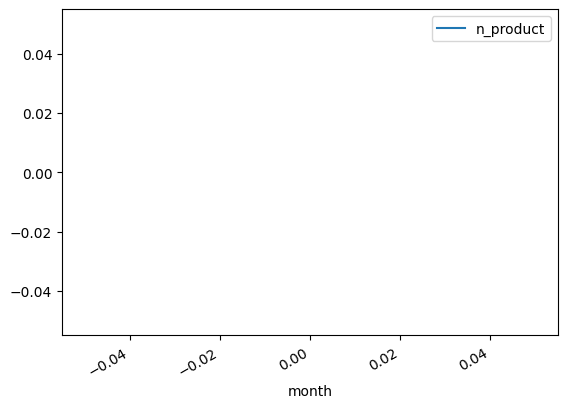

In [38]:
# what is the launching trend for dog keyword?
target="chiffon"
cat='Appliances'
keyword_df[keyword_df['keyword']==target][keyword_df['cat']==cat].plot(x='month',y='n_product')

In [39]:
# top 10 keywords of pet catogories
keyword_agg[keyword_agg['cat']==cat].sort_values(by='n_product',ascending=False)[:20]

,keyword,cat,n_product,avg_price_median,avg_velocity_median
11900,compatible,Appliances,16,48.890455,0.023496
40092,replacement,Appliances,15,51.005000,0.024538
30119,machine,Appliances,11,52.042857,0.033347
11941,compatible with,Appliances,11,47.915625,0.016541
46563,stove,Appliances,10,49.376667,0.045510
34815,oven,Appliances,9,49.917857,0.048563
52691,washer,Appliances,9,51.577500,0.037297
52701,washing,Appliances,9,50.330000,0.029384
51390,upgraded,Appliances,9,56.117500,0.034079
46188,steel,Appliances,9,59.864375,0.026816


# Let's focus on kitchen

In [40]:
df_kitchen=df[df['cat']=='Home & Kitchen'] #5000
df_kitchen_filtered=df_kitchen[df_kitchen['most_recent_review_time']>=90] #3400
df_kitchen_filtered[df_kitchen_filtered['review_velocity']>=0.056].shape # 5 review at 90 days. 321


(321, 395)

# script amazon to add back review data (1950/5400 missing review data).

In [41]:
kitchen_lesss_than_90days=df_kitchen[df_kitchen['most_recent_review_time']<90]
kitchen_lesss_than_90days
# kitchen_lesss_than_90days.to_csv(f'{file_path}kitchen_lesss_than_90days.csv')

,asin,seller,cat,price,title,most_recent_review,most_recent_review_time,launch_year,launch_month,launch_year_month,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
1310,B0CLRZH2MP,A318BG35C9M0OR,Home & Kitchen,97.29,"Boolegon New Update 1.5""Linen Cellular Shade N...",0,-107,2024,2,2024-02-01,...,-0.046190,-0.079987,0.007757,0.057861,-0.022749,-0.039289,0.017928,-0.038551,-0.071349,0.046829
1323,B0CLS1ZCXG,A318BG35C9M0OR,Home & Kitchen,97.81,"Boolegon New Update 1.5""Linen Cellular Shade N...",0,-107,2024,2,2024-02-01,...,-0.045199,-0.077871,0.011318,0.057385,-0.015727,-0.033051,0.020789,-0.039688,-0.070870,0.047562
1397,B0CLRZ8QV6,A318BG35C9M0OR,Home & Kitchen,92.96,"Boolegon New Update 1.5"" Linen Cellular Shade ...",0,13,2024,2,2024-02-01,...,-0.045998,-0.059728,0.022710,0.047994,-0.031647,-0.043582,0.027355,-0.038849,-0.080486,0.064167
1422,B0CWL8QNKT,A4LEAT77675UO,Home & Kitchen,25.99,AMHNF Funny Cat Shower Curtain Blue Teal Ocean...,0,24,2024,2,2024-02-01,...,0.011793,-0.036195,-0.012148,0.043182,0.006348,0.054126,0.011357,0.022845,-0.012920,0.036156
1456,B0CLRZ1F2B,A318BG35C9M0OR,Home & Kitchen,87.48,"Boolegon New Update 1.5"" Linen Cellular Shade ...",0,40,2024,2,2024-02-01,...,-0.049592,-0.069054,0.028343,0.050553,-0.027717,-0.041794,0.024452,-0.040967,-0.083535,0.064942
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61602,B0FHKVLQPD,A2P3CZ21UHQ0TO,Home & Kitchen,29.99,"90L Portable Laundry Basket, Collapsible Laund...",0,-167,2026,3,2026-03-01,...,0.012319,0.068468,-0.052238,-0.029617,-0.010069,0.029307,0.018906,-0.034709,-0.062536,-0.071820
61610,B0GSV439VK,A31B9ZEEXQXWK3,Home & Kitchen,45.08,"Outdoor Bamboo Shades for Patio, Natural Bambo...",0,13,2026,3,2026-03-01,...,-0.055277,0.022697,0.050071,0.066318,-0.024547,-0.021549,-0.064745,-0.061823,-0.094182,0.066712
61618,B0F8J1XM9P,A1P18CKRCMWOK2,Home & Kitchen,21.99,Kxnwlej Hand Hooked Cat Rug Orange Tabby Shape...,3,-84,2026,3,2026-03-01,...,-0.053170,-0.047669,-0.061272,-0.004405,0.080989,0.077894,0.087318,-0.027878,-0.016920,0.025361
61622,B0GR87DDR5,A2LJAFESLN1CQH,Home & Kitchen,40.00,PMU 3 Pcs Green St. Patricks Day Hat with Buck...,0,8,2026,3,2026-03-01,...,-0.037265,0.022481,-0.004457,0.078844,0.035832,-0.043715,-0.015927,-0.061488,-0.067461,0.002316


In [42]:
df_keyword=pd.read_csv(f'{file_path}kitchen_review_counts.csv')
# rename it
df_keyword['script_review_count_at_May122026']=df_keyword['review_count']
# get the ones we are sure are losers Jan2024-Dec2025; the ones not 0 we are not sure about the contribution
new_scripted_loser_asin=df_keyword[df_keyword['script_review_count_at_May122026']==0]['asin'].tolist()
len(new_scripted_loser_asin)

961

In [43]:
# add back these new losers to df_kitchen
df_kitchen_modified=df_kitchen.copy()

today = pd.to_datetime('2026-05-12')

mask = df_kitchen_modified['asin'].isin(new_scripted_loser_asin)

df_kitchen_modified.loc[mask, 'most_recent_review_time'] = (
    today - df_kitchen_modified.loc[mask, 'launch_year_month']
).dt.days

df_kitchen_modified.loc[mask, 'most_recent_review'] = 0



# keep sample with review data >=90 days

In [44]:
df_kitchen_modified_90=df_kitchen_modified[df_kitchen_modified['most_recent_review_time']>90] # 4215
len(df_kitchen_modified_90)

4215

In [45]:
df_kitchen_modified_90['review_velocity']=df_kitchen_modified_90['most_recent_review']/df_kitchen_modified_90['most_recent_review_time']
df_kitchen_modified_90.head()

,asin,seller,cat,price,title,most_recent_review,most_recent_review_time,launch_year,launch_month,launch_year_month,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
37,B0CSFZYQ6Y,AL2EU444ISCFJ,Home & Kitchen,39.99,GUBIYU Farmhouse Kitchen Rugs Sets 3 Piece wit...,0,242,2024,1,2024-01-01,...,-0.025024,-0.049795,0.029813,-0.068001,0.094769,0.024119,0.032034,-0.057843,-0.050446,0.053053
101,B0CSJZHZRB,AL2EU444ISCFJ,Home & Kitchen,39.99,GUBIYU Farmhouse Area Rugs Runner Black Gold P...,0,649,2024,1,2024-01-01,...,0.023684,-0.056711,-0.033992,-0.041751,0.023504,0.064650,0.090797,-0.060913,-0.067357,0.039459
116,B0CSJZDTHL,AL2EU444ISCFJ,Home & Kitchen,39.99,GUBIYU Black Brown Farmhouse Area Rugs Runner ...,0,650,2024,1,2024-01-01,...,0.024133,-0.064096,-0.024705,-0.054012,0.020888,0.085841,0.095203,-0.072363,-0.046585,0.043940
162,B0CSK84JM6,AL2EU444ISCFJ,Home & Kitchen,39.99,GUBIYU Set of 2 Kitchen Rugs and Mats Farmhous...,0,719,2024,1,2024-01-01,...,-0.005245,-0.034901,0.021479,-0.080927,0.105166,0.044825,0.047724,-0.073821,-0.052206,0.045662
187,B0CSJRF4M9,AL2EU444ISCFJ,Home & Kitchen,39.99,GUBIYU Blue Black Yellow Patchwork Rugs Area R...,0,241,2024,1,2024-01-01,...,0.005250,-0.071591,-0.010855,-0.028029,0.023101,0.059545,0.078770,-0.075742,-0.044172,0.063717


# Feature Engineering

In [46]:
df_kitchen_modified_90_split=df_kitchen_modified_90[df_kitchen_modified_90['launch_year_month']<=pd.to_datetime('2025-12-01')]

In [47]:
# Get the target product's details

import pandas as pd
from datetime import timedelta
from sklearn.feature_extraction.text import CountVectorizer


def extract_keywords_from_text(text):
  """Extracts unigrams and bigrams from a given text using CountVectorizer."""
  cv_clean = CountVectorizer(ngram_range=(1,2), min_df=1)
  # Fit and transform the text
  keyword_freq = cv_clean.fit_transform([text])
  keywords = cv_clean.get_feature_names_out()
  return keywords

def get_competitor_data(row):
  """
  A function used to get current item's competitor(based on keywords) infor from previous month.

  Input: row form df
  Output: competitor avg_n_product, sum_n_product, max_n_product, avg_price_median, max_price_median
  """

  CATOGERY='Home & Kitchen'

  target_product_title = row['title']
  target_launch_month = row['launch_year_month']

  previous_month = (target_launch_month - pd.DateOffset(months=1)).to_period('M').start_time
  target_keywords = extract_keywords_from_text(target_product_title)

  competitive_keywords_in_previous_month = keyword_df[
    (keyword_df['keyword'].isin(target_keywords)) &
    (keyword_df['month'] == previous_month) &
    (keyword_df['cat'] == CATOGERY)
  ].copy()

  if not competitive_keywords_in_previous_month.empty:
    avg_n_product = competitive_keywords_in_previous_month['n_product'].mean()
    sum_n_product = competitive_keywords_in_previous_month['n_product'].sum()
    max_n_product = competitive_keywords_in_previous_month['n_product'].max()
    avg_price_median = competitive_keywords_in_previous_month['price_median'].mean()
    return pd.Series({
        'avg_n_product': avg_n_product,
        'sum_n_product': sum_n_product,
        'max_n_product': max_n_product,
        'avg_price_median': avg_price_median,

    })

  else:
    return pd.Series({
        'avg_n_product': 0,
        'sum_n_product': 0,
        'max_n_product': 0,
        'avg_price_median': None,
    })

In [48]:
competitor_df = df_kitchen_modified_90_split.apply(get_competitor_data, axis=1)


In [49]:
df_kitchen_modified_90_split=pd.concat([df_kitchen_modified_90_split,competitor_df],axis=1)


In [50]:
# get rid of jan 2024 since it does not competitior data
df_kitchen_modified_90_split=df_kitchen_modified_90_split[df_kitchen_modified_90_split['launch_year_month']>'2024-01-01']

In [51]:
df_kitchen_modified_90_split['label']=np.where(df_kitchen_modified_90_split['review_velocity']>=0.056,1,0)
df_kitchen_modified_90_split['label'].value_counts()

,count
label,
0,3640
1,312


In [52]:
train_raw=df_kitchen_modified_90_split[df_kitchen_modified_90_split['launch_year_month']<=pd.to_datetime('2025-09-01')]
test_raw=df_kitchen_modified_90_split[df_kitchen_modified_90_split['launch_year_month']>pd.to_datetime('2025-09-01')]
len(train_raw)/len(df_kitchen_modified_90_split)

0.8165485829959515

In [53]:
features=df_kitchen_modified_90_split.columns.tolist()
target='label'

features.remove(target)

X_train=train_raw[features]
y_train=train_raw[target]

X_test=test_raw[features]
y_test=test_raw[target]

y_train.shape


(3227,)

In [54]:
# feature: title, price, launch_month, launch_year,avg_n_product,sum_n_product,max_n_product,avg_price_median
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#'avg_n_product','sum_n_product','max_n_product','avg_price_median'
#("tfidf", TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2)), "title")
# 'launch_year','launch_month',
preprocessing = ColumnTransformer(
    [("numeric", SimpleImputer(strategy='median'), ['price']),
    ("tfidf", TfidfVectorizer(max_features=500, stop_words='english', ngram_range=(1,2)), "title")
     ]
)

#'avg_n_product','sum_n_product','max_n_product','avg_price_median'
steps=[
    ('preprocessing', preprocessing),
    ('xgb', XGBClassifier())
]

pipe=Pipeline(steps)

model=pipe.fit(X_train,y_train)

In [55]:
from sklearn.metrics import classification_report,roc_auc_score

y_prob=model.predict_proba(X_test)

THRESHOLD=0.6
y_pred=(y_prob[:,1]>THRESHOLD).astype(int)

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.92      0.99      0.95       663
           1       0.36      0.08      0.13        62

    accuracy                           0.91       725
   macro avg       0.64      0.53      0.54       725
weighted avg       0.87      0.91      0.88       725



In [56]:
import numpy as np

def precision_at_k(y_true, y_prob, k):
    # rank by probability descending # return index
    top_k_idx=np.argsort(y_prob)[::-1][:k]
    return y_true.iloc[top_k_idx].mean()

baseline = y_test.mean()  # ~0.085 (8.5% positive rate)

for k in [10, 20, 50]:
    p_at_k = precision_at_k(y_test, y_prob[:,1], k)
    lift = p_at_k / baseline
    print(f"P@{k}: {p_at_k:.2f}  |  Lift: {lift:.1f}x  |  baseline: {baseline:.2f}")

P@10: 0.40  |  Lift: 4.7x  |  baseline: 0.09
P@20: 0.30  |  Lift: 3.5x  |  baseline: 0.09
P@50: 0.24  |  Lift: 2.8x  |  baseline: 0.09


In [57]:
from sklearn.metrics import ndcg_score
import numpy as np

# y_prob from your model
y_prob = model.predict_proba(X_test)[:, 1]

# --- binary label version ---
ndcg_at_20 = ndcg_score([y_test.values], [y_prob], k=20)
print(f"NDCG@20 (binary): {ndcg_at_20:.3f}")

# --- graded relevance version (better) ---
# use review_velocity directly — rewards ranking a 0.2 velocity product
# above a 0.05 velocity product, not just success vs failure
y_velocity = test_raw['review_velocity'].fillna(0).values

ndcg_at_20_graded = ndcg_score([y_velocity], [y_prob], k=20)
print(f"NDCG@20 (graded): {ndcg_at_20_graded:.3f}")


NDCG@20 (binary): 0.406
NDCG@20 (graded): 0.187


In [58]:
from xgboost import XGBRegressor

# filter to rows with review data
train_reg = train_raw[train_raw['review_velocity'].notna()]
test_reg  = test_raw[test_raw['review_velocity'].notna()]

pipe_reg = Pipeline([
    ('preprocessing', preprocessing),
    ('xgb', XGBRegressor())
])

model_reg = pipe_reg.fit(X_train,y_train)

y_score = model_reg.predict(X_test)  # predicted log velocity
y_velocity = test_reg['review_velocity'].fillna(0).values

ndcg_graded = ndcg_score([y_velocity], [y_score], k=20)
print(f"NDCG@20 (graded): {ndcg_graded:.3f}")


NDCG@20 (graded): 0.241


In [59]:
from xgboost import XGBRegressor
from sklearn.metrics import ndcg_score
import numpy as np

def precision_at_k(y_true_binary, y_score, k):
    top_k_idx = np.argsort(y_score)[::-1][:k]
    return y_true_binary[top_k_idx].sum() / k

# filter to rows with review data
train_reg = train_raw[train_raw['review_velocity'].notna()]
test_reg  = test_raw[test_raw['review_velocity'].notna()]

pipe_reg = Pipeline([
    ('preprocessing', preprocessing),
    ('xgb', XGBRegressor())
])

model_reg = pipe_reg.fit(train_reg[features], np.log1p(train_reg['review_velocity']))

y_score    = model_reg.predict(test_reg[features])
y_velocity = test_reg['review_velocity'].fillna(0).values
y_binary   = (test_reg['review_velocity'] >= 0.056).astype(int).values

for k in [10, 20, 50]:
    ndcg = ndcg_score([y_velocity], [y_score], k=k)
    p_at_k = precision_at_k(y_binary, y_score, k)
    print(f"K={k:>2}  NDCG@K: {ndcg:.3f}  Precision@K: {p_at_k:.3f}")


K=10  NDCG@K: 0.141  Precision@K: 0.300
K=20  NDCG@K: 0.180  Precision@K: 0.400
K=50  NDCG@K: 0.231  Precision@K: 0.320


In [60]:
pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.6/753.6 kB 8.8 MB/s eta 0:00:00


In [ ]:
import anthropic

# ── 1. Build context from your data ──────────────────────────────────────

def get_trending_keywords(keyword_df, cat='Home & Kitchen', top_n=20):
    """Keywords with growing launch volume in last 3 months vs prior 3 months."""
    recent_months = sorted(keyword_df['month'].unique())
    last_3  = recent_months[-3:]
    prior_3 = recent_months[-6:-3]

    recent = keyword_df[keyword_df['month'].isin(last_3)].groupby('keyword')['n_product'].sum()
    prior  = keyword_df[keyword_df['month'].isin(prior_3)].groupby('keyword')['n_product'].sum()

    trend = pd.DataFrame({'recent': recent, 'prior': prior}).fillna(0)
    trend['growth'] = trend['recent'] - trend['prior']
    trend['velocity'] = keyword_df.groupby('keyword')['velocity_median'].mean()

    return trend[trend['recent'] >= 5].sort_values('growth', ascending=False).head(top_n)

def get_top_seller_recent_products(df, seller_stats, n_sellers=10, n_months=3):
    """Recent titles from top sellers by success rate."""
    top_sellers = (
        seller_stats[seller_stats['n_products'] >= 3]
        .sort_values('success_rate', ascending=False)
        .head(n_sellers)['seller'].tolist()
    )
    recent_months = sorted(df['launch_year_month'].unique())[-n_months:]
    return (
        df[df['seller'].isin(top_sellers) & df['launch_year_month'].isin(recent_months)]
        [['seller', 'title', 'price', 'review_velocity', 'launch_year_month']]
        .sort_values('review_velocity', ascending=False)
    )

# ── 2. RAG query function ─────────────────────────────────────────────────

def rag_market_analysis(query, keyword_df, df, seller_stats):
    trending   = get_trending_keywords(keyword_df)
    top_products = get_top_seller_recent_products(df, seller_stats)

    context = f"""
TRENDING KEYWORDS — Home & Kitchen (last 3 months vs prior 3 months):
{trending[['recent','prior','growth','velocity']].to_string()}

TOP SELLER RECENT PRODUCTS:
{top_products[['title','price','review_velocity','launch_year_month']].to_string()}
"""

    client = anthropic.Anthropic()
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1024,
        system="You are an Amazon market analyst. Answer based only on the data provided. Be specific and actionable.",
        messages=[{
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": context,
                    "cache_control": {"type": "ephemeral"}  # cache static context
                },
                {
                    "type": "text",
                    "text": query
                }
            ]
        }]
    )
    return response.content[0].text

# ── 3. Usage ──────────────────────────────────────────────────────────────

print(rag_market_analysis(
    "What niches are top sellers moving into? What keywords are trending and at what price points?",
    keyword_df, df_kitchen_modified_90, seller_stats
))
